<a href="https://colab.research.google.com/github/Abhay-07082005/food-freshness-app/blob/main/freshsense_AI_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib pandas scikit-learn -q


In [2]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [11]:
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

DATASET_PATH = "/content/dataset/Fruits_Vegetables_Dataset(12000)/Fruits"
print("Dataset extracted to:", DATASET_PATH)

Dataset extracted to: /content/dataset/Fruits_Vegetables_Dataset(12000)/Fruits


In [12]:

QUALITY_BASE_SCORE = {
    "fresh": 95,
    "mixed": 65,
    "medium": 65,
    "good": 65,
    "rotten": 20,
    "bad": 20,
}
MAX_SHELF_LIFE_DAYS = {
    "apple": 30,
    "banana": 7,
    "guava": 5,
    "lemon": 30,
    "orange": 21,
    "pomegranate": 60,
}

JITTER_STD = 6.0

def parse_folder_name(folder_name):
    """Extract (fruit, quality) from a folder name like 'freshapple' or 'rottenbanana'."""
    name = folder_name.lower()
    quality = "mixed"
    for q in ["fresh", "rotten", "bad", "mixed", "medium", "good"]:
        if q in name:
            quality = q
            name = name.replace(q, "")
            break
    fruit = name.strip("_- ")
    for known_fruit in MAX_SHELF_LIFE_DAYS:
        if known_fruit in name:
            fruit = known_fruit
            break
    return fruit, quality

def compute_labels(fruit, quality, rng):
    base = QUALITY_BASE_SCORE.get(quality, 65)
    freshness_pct = float(np.clip(base + rng.normal(0, JITTER_STD), 0, 100))
    max_days = MAX_SHELF_LIFE_DAYS.get(fruit, 14)
    days_left = round(max_days * (freshness_pct / 100.0))
    return freshness_pct, days_left

In [46]:
rng = np.random.default_rng(SEED)

records = []
for folder_name in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue
    fruit, quality = parse_folder_name(folder_name)
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        freshness_pct, days_left = compute_labels(fruit, quality, rng)
        records.append({
            "filepath": os.path.join(folder_path, fname),
            "fruit": fruit,
            "quality": quality,
            "freshness_pct": freshness_pct,
            "days_left": days_left,
        })

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 5988


,filepath,fruit,quality,freshness_pct,days_left
0,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,89.065272,27
1,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,92.793280,28
2,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,100.000000,30
3,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,96.163847,29
4,/content/dataset/Fruits_Vegetables_Dataset(120...,apple,fresh,100.000000,30


In [47]:
class_names = sorted(df["fruit"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}
df["fruit_idx"] = df["fruit"].map(class_to_index)

print("Classes:", class_names)

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["fruit_idx"]
)
print("Train size:", len(train_df), "| Val size:", len(val_df))


Classes: ['apple', 'banana', 'mango', 'orange', 'strawberry']
Train size: 4790 | Val size: 1198


In [15]:
import os

print(os.listdir("/content/dataset/Fruits_Vegetables_Dataset(12000)"))

['Fruits', 'Vegetables']


In [49]:
def load_image(filepath):
  img = tf.io.read_file(filepath)

  img = tf.io.decode_image(
      img,
      channels=3,
      expand_animations=False
  )
  img.set_shape([None, None, 3])
  img = tf.image.resize(img, IMG_SIZE)
  img = preprocess_input(img)

  return img

def make_dataset(dataframe, training=False):
    filepaths = dataframe["filepath"].values
    fruit_idx = dataframe["fruit_idx"].values.astype("int32")
    freshness = dataframe["freshness_pct"].values.astype("float32")
    days = dataframe["days_left"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((filepaths, fruit_idx, freshness, days))

    def _map_fn(fp, f_idx, fresh, dl):
        img = load_image(fp)
        labels = {
            "fruit_class": f_idx,
            "freshness_pct": fresh,
            "days_left": dl,
        }
        return img, labels

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)


In [51]:
num_classes = len(class_names)

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze pretrained backbone initially

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
h = layers.Dense(128, activation="relu")(x)

fruit_class_out = layers.Dense(num_classes, activation="softmax", name="fruit_class")(h)

freshness_raw = layers.Dense(1, activation="sigmoid")(h)
freshness_pct_out = layers.Lambda(lambda t: t * 100.0, name="freshness_pct")(freshness_raw)

days_left_out = layers.Dense(1, activation="relu", name="days_left")(h)

model = Model(inputs=inputs, outputs=[fruit_class_out, freshness_pct_out, days_left_out])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_5[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fruit_class (Dense) │ (None, 5)         │        645 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ freshness_pct       │ (None, 1)         │          0 │ dense_5[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ days_left (Dense)   │ (None, 1)         │        129 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [52]:
model.compile(
    optimizer="adam",
    loss={
        "fruit_class": "sparse_categorical_crossentropy",
        "freshness_pct": "mse",
        "days_left": "mse",
    },
    loss_weights={
        "fruit_class": 1.0,
        "freshness_pct": 0.01,
        "days_left": 0.01,
    },
    metrics={
        "fruit_class": "accuracy",
        "freshness_pct": "mae",
        "days_left": "mae",
    },
)


In [53]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - days_left_loss: 46.2699 - days_left_mae: 4.7737 - freshness_pct_loss: 407.1813 - freshness_pct_mae: 13.8049 - fruit_class_accuracy: 0.8347 - fruit_class_loss: 0.4681 - loss: 5.0058 - val_days_left_loss: 21.0889 - val_days_left_mae: 3.1318 - val_freshness_pct_loss: 205.6796 - val_freshness_pct_mae: 10.2331 - val_fruit_class_accuracy: 0.9633 - val_fruit_class_loss: 0.1278 - val_loss: 2.4178
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - days_left_loss: 16.4176 - days_left_mae: 2.8495 - freshness_pct_loss: 174.3513 - freshness_pct_mae: 9.3306 - fruit_class_accuracy: 0.9595 - fruit_class_loss: 0.1432 - loss: 2.0504 - val_days_left_loss: 14.8221 - val_days_left_mae: 2.5398 - val_freshness_pct_loss: 128.2113 - val_freshness_pct_mae: 7.8525 - val_fruit_class_accuracy: 0.9750 - val_fruit_class_loss: 0.0705 - val_loss: 1.5112
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - days_left_loss: 13.4247 - days_left_mae: 2.5622 - fre

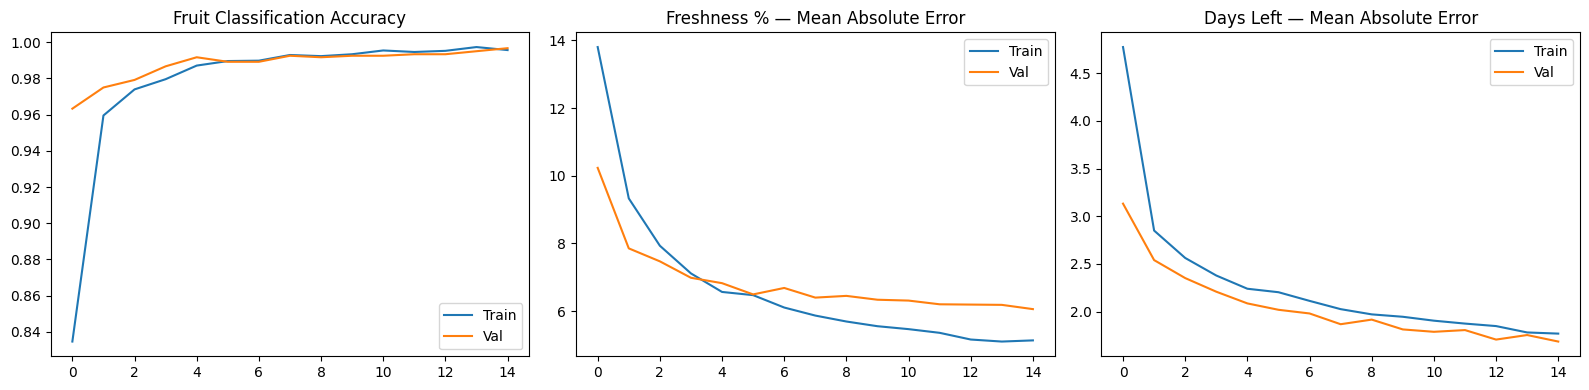

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["fruit_class_accuracy"], label="Train")
axes[0].plot(history.history["val_fruit_class_accuracy"], label="Val")
axes[0].set_title("Fruit Classification Accuracy")
axes[0].legend()

axes[1].plot(history.history["freshness_pct_mae"], label="Train")
axes[1].plot(history.history["val_freshness_pct_mae"], label="Val")
axes[1].set_title("Freshness % — Mean Absolute Error")
axes[1].legend()

axes[2].plot(history.history["days_left_mae"], label="Train")
axes[2].plot(history.history["val_days_left_mae"], label="Val")
axes[2].set_title("Days Left — Mean Absolute Error")
axes[2].legend()

plt.tight_layout()
plt.show()


In [55]:
model.save("food_freshness_model_v2.keras")
print("Model saved successfully!")


Model saved successfully!
